In [1]:
from sympy import *
import numpy as np
import matplotlib.pyplot as plt

# Q. 46

## (a)

In [2]:
x, y, c = symbols('x y c')

In [3]:
M = 2*x*y/(x**2 + y**2)**2
N = 1 + (y**2 - x**2)/(x**2 + y**2)**2

In [4]:
if simplify(diff(M, y) - diff(N, x)) == 0:
    print("EXACT EQUATION")
else:
    print("NOT EXACT EQUATION")

EXACT EQUATION


In [5]:
g = Function('g')
g(y)

g(y)

In [6]:
F = integrate(M, x) + g(y)
F

-2*y/(2*x**2 + 2*y**2) + g(y)

In [7]:
dF_dy = diff(F, y)
dF_dy

8*y**2/(2*x**2 + 2*y**2)**2 + Derivative(g(y), y) - 2/(2*x**2 + 2*y**2)

In [8]:
dg_dy = symbols('dg_dy')
expr = dF_dy.subs(Derivative(g(y), y), dg_dy)
expr

dg_dy + 8*y**2/(2*x**2 + 2*y**2)**2 - 2/(2*x**2 + 2*y**2)

In [9]:
dg_dy_sol = solve(Eq(expr, N), dg_dy)[0]
dg_dy_sol

1

In [10]:
g_sol = integrate(dg_dy_sol, y)
g_sol

y

In [11]:
F_final = F.subs(g(y), g_sol)
F_final

y - 2*y/(2*x**2 + 2*y**2)

## (b)

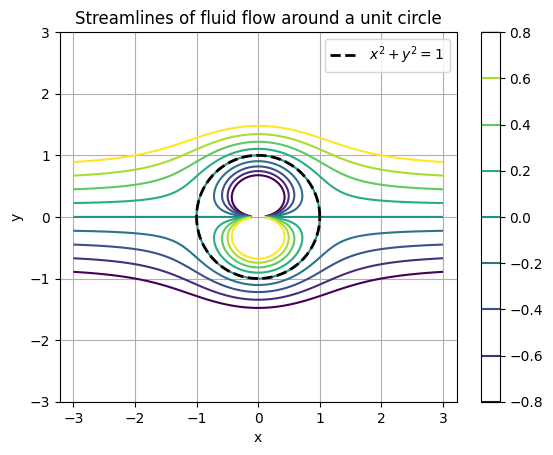

In [31]:
X, Y = np.meshgrid(np.linspace(-3, 3, 400), np.linspace(-3, 3, 400))

# Mask near origin to avoid singularity
R2 = X**2 + Y**2
Z = np.where(R2 < 0.01, np.nan, Y - Y/R2)

levels = sorted([0, 0.2, -0.2, 0.4, -0.4, 0.6, -0.6, 0.8, -0.8])
contours = plt.contour(X, Y, Z, levels=levels)

# Add the boundary circle x² + y² = 1
theta = np.linspace(0, 2*np.pi, 300)
plt.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=2, label='$x^2+y^2=1$')

plt.xlabel("x")
plt.ylabel("y")
plt.colorbar(contours)
plt.legend()
plt.axis('equal')       # important so circle looks like a circle
plt.grid(True)
plt.title("Streamlines of fluid flow around a unit circle")
plt.show()

[sqrt(y*(-c*y + y**2 - 1)/(c - y)), -sqrt(-y*(c*y - y**2 + 1)/(c - y))]


<lambdifygenerated-126>:2: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(1 - y**2)
<lambdifygenerated-127>:2: RuntimeWarning: invalid value encountered in sqrt
  return -sqrt(1 - y**2)
<lambdifygenerated-128>:2: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(y*(y**2 - 0.2*y - 1)/(0.2 - y))
<lambdifygenerated-129>:2: RuntimeWarning: invalid value encountered in sqrt
  return -sqrt(-y*(-y**2 + 0.2*y + 1)/(0.2 - y))
<lambdifygenerated-130>:2: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(y*(y**2 + 0.2*y - 1)/(-y - 0.2))
<lambdifygenerated-131>:2: RuntimeWarning: invalid value encountered in sqrt
  return -sqrt(-y*(-y**2 - 0.2*y + 1)/(-y - 0.2))
<lambdifygenerated-132>:2: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(y*(y**2 - 0.4*y - 1)/(0.4 - y))
<lambdifygenerated-133>:2: RuntimeWarning: invalid value encountered in sqrt
  return -sqrt(-y*(-y**2 + 0.4*y + 1)/(0.4 - y))
<lambdifygenerated-134>:2: RuntimeWarning: inval

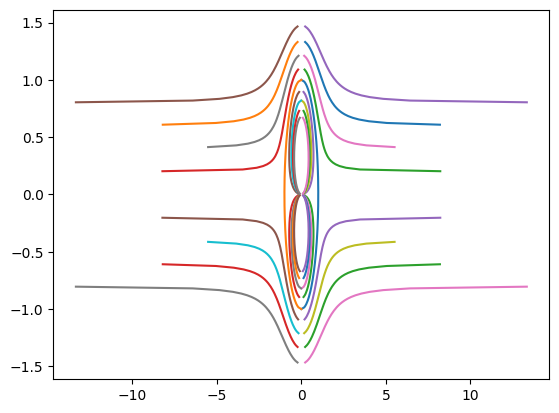

In [38]:
x, y, c = symbols('x y c', real=True)

F_expr = y - y/(x**2 + y**2)

# Solve F = c for x
sols_x = solve(Eq(F_expr, c), x)
print(sols_x)  # Two branches: +/- 

# Convert to numpy functions and plot each branch for each c value
for c_val in [0, 0.2, -0.2, 0.4, -0.4, 0.6, -0.6, 0.8, -0.8]:
    for sol in sols_x:
        f_num = lambdify(y, sol.subs(c, c_val), 'numpy')
        y_vals = np.linspace(-3, 3, 400)
        x_vals = f_num(y_vals)
        plt.plot(x_vals, y_vals)  # note: x is horizontal axis

In [39]:
sols_y = solve(Eq(F_expr, c), y)
print(sols_y) 

[c/3 - (c**2 - 3*x**2 + 3)/(3*(-c**3 - 27*c*x**2/2 + 9*c*(x**2 - 1)/2 + sqrt(-4*(c**2 - 3*x**2 + 3)**3 + (-2*c**3 - 27*c*x**2 + 9*c*(x**2 - 1))**2)/2)**(1/3)) - (-c**3 - 27*c*x**2/2 + 9*c*(x**2 - 1)/2 + sqrt(-4*(c**2 - 3*x**2 + 3)**3 + (-2*c**3 - 27*c*x**2 + 9*c*(x**2 - 1))**2)/2)**(1/3)/3, c/3 - (c**2 - 3*x**2 + 3)/(3*(-1/2 - sqrt(3)*I/2)*(-c**3 - 27*c*x**2/2 + 9*c*(x**2 - 1)/2 + sqrt(-4*(c**2 - 3*x**2 + 3)**3 + (-2*c**3 - 27*c*x**2 + 9*c*(x**2 - 1))**2)/2)**(1/3)) - (-1/2 - sqrt(3)*I/2)*(-c**3 - 27*c*x**2/2 + 9*c*(x**2 - 1)/2 + sqrt(-4*(c**2 - 3*x**2 + 3)**3 + (-2*c**3 - 27*c*x**2 + 9*c*(x**2 - 1))**2)/2)**(1/3)/3, c/3 - (c**2 - 3*x**2 + 3)/(3*(-1/2 + sqrt(3)*I/2)*(-c**3 - 27*c*x**2/2 + 9*c*(x**2 - 1)/2 + sqrt(-4*(c**2 - 3*x**2 + 3)**3 + (-2*c**3 - 27*c*x**2 + 9*c*(x**2 - 1))**2)/2)**(1/3)) - (-1/2 + sqrt(3)*I/2)*(-c**3 - 27*c*x**2/2 + 9*c*(x**2 - 1)/2 + sqrt(-4*(c**2 - 3*x**2 + 3)**3 + (-2*c**3 - 27*c*x**2 + 9*c*(x**2 - 1))**2)/2)**(1/3)/3]


<lambdifygenerated-144>:2: RuntimeWarning: invalid value encountered in power
  return -1/3*(-(3 - 3*x**2)**3)**(1/6) - 1/3*(3 - 3*x**2)/(-(3 - 3*x**2)**3)**(1/6)
<lambdifygenerated-144>:2: RuntimeWarning: invalid value encountered in divide
  return -1/3*(-(3 - 3*x**2)**3)**(1/6) - 1/3*(3 - 3*x**2)/(-(3 - 3*x**2)**3)**(1/6)
<lambdifygenerated-145>:2: RuntimeWarning: invalid value encountered in power
  return -1/3*(-(3 - 3*x**2)**3)**(1/6)*(-1/2 - 1/2*sqrt(3)*1j) - 1/3*(3 - 3*x**2)/((-(3 - 3*x**2)**3)**(1/6)*(-1/2 - 1/2*sqrt(3)*1j))
<lambdifygenerated-145>:2: RuntimeWarning: invalid value encountered in divide
  return -1/3*(-(3 - 3*x**2)**3)**(1/6)*(-1/2 - 1/2*sqrt(3)*1j) - 1/3*(3 - 3*x**2)/((-(3 - 3*x**2)**3)**(1/6)*(-1/2 - 1/2*sqrt(3)*1j))
/home/sonu/miniconda3/envs/adv_eng_math_cla/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/sonu/miniconda3/envs/adv_eng_math_cla/

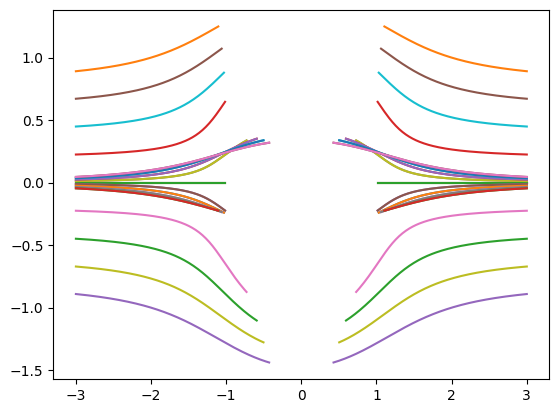

In [40]:
# Convert to numpy functions and plot each branch for each c value
for c_val in [0, 0.2, -0.2, 0.4, -0.4, 0.6, -0.6, 0.8, -0.8]:
    for sol in sols_y:
        f_num = lambdify(x, sol.subs(c, c_val), 'numpy')
        x_vals = np.linspace(-3, 3, 400)
        y_vals = f_num(x_vals)
        plt.plot(x_vals, y_vals)  # note: x is horizontal axis